1️⃣ Load dataset
2️⃣ Dataset shape 

In [9]:
import pandas as pd

df = pd.read_csv(r"C:\Users\User\Desktop\project\video_pipeline\ml\training\event_dataset_raw.csv")

df.shape


(286, 21)

3️⃣ Sample rows

In [10]:
df.head()

,video_id,video_name,camera_name,window_start_sec,window_end_sec,representative_frame_id,representative_frame_name,representative_frame_path,max_confidence,avg_confidence,...,fire_smoke_ratio,bbox_area_ratio,detection_density_5s,detection_density_10s,avg_confidence_5s,consecutive_fire_ratio,bbox_area_growth,brightness,blur_score,motion_level
0,1,cam01_car_fire.mp4,cam01,0,5,146,cam01_frame_146.jpg,video_pipeline/output/saved_frames/cam01_frame...,0.957943,0.504024,...,0.700855,0.728223,4.680000,2.340000,0.504024,0.993333,0.117237,118.250464,309.147544,15.139262
1,1,cam01_car_fire.mp4,cam01,1,6,146,cam01_frame_146.jpg,video_pipeline/output/saved_frames/cam01_frame...,0.957943,0.526409,...,0.693972,0.702688,4.313333,2.550000,0.526409,1.000000,-0.433285,119.294667,309.776753,14.172786
2,1,cam01_car_fire.mp4,cam01,2,7,202,cam01_frame_202.jpg,video_pipeline/output/saved_frames/cam01_frame...,0.975177,0.543022,...,0.773994,0.702688,4.306667,3.083333,0.543022,1.000000,0.130569,121.708687,327.499147,16.139979
3,1,cam01_car_fire.mp4,cam01,3,8,202,cam01_frame_202.jpg,video_pipeline/output/saved_frames/cam01_frame...,0.975177,0.543454,...,0.799722,0.784026,4.793333,3.810000,0.543454,1.000000,0.323905,121.043020,359.171380,17.321970
4,1,cam01_car_fire.mp4,cam01,4,9,202,cam01_frame_202.jpg,video_pipeline/output/saved_frames/cam01_frame...,0.975177,0.564547,...,0.841176,0.784026,5.666667,4.630000,0.564547,1.000000,1.039767,119.742680,393.648213,17.445870


4️⃣ Feature statistics

In [11]:
df.describe().round(3)

,video_id,window_start_sec,window_end_sec,representative_frame_id,max_confidence,avg_confidence,object_count,fire_smoke_ratio,bbox_area_ratio,detection_density_5s,detection_density_10s,avg_confidence_5s,consecutive_fire_ratio,bbox_area_growth,brightness,blur_score,motion_level
count,286.000,286.000,286.000,286.000,286.000,286.000,286.000,286.000,286.000,286.000,286.000,286.000,286.000,286.000,286.000,286.000,286.000
mean,5.465,28.322,33.322,4207.276,0.690,0.416,5.176,0.748,0.558,4.463,4.204,0.416,0.783,0.138,107.621,448.371,6.108
std,2.039,23.562,23.562,2075.185,0.179,0.075,4.966,0.266,0.237,4.038,3.578,0.075,0.312,0.750,26.268,220.996,7.952
min,1.000,0.000,5.000,146.000,0.297,0.269,1.000,0.000,0.005,0.008,0.052,0.269,0.000,-0.990,49.610,105.040,0.464
25%,4.000,7.000,12.000,2452.750,0.557,0.364,1.824,0.528,0.405,1.544,1.582,0.364,0.527,-0.196,86.655,269.339,2.510
50%,5.000,22.500,27.500,4514.000,0.716,0.413,3.866,0.836,0.639,3.559,3.046,0.413,0.994,0.005,114.410,435.982,4.952
75%,6.000,46.000,51.000,5775.750,0.825,0.474,6.097,1.000,0.730,5.886,6.468,0.474,1.001,0.217,123.363,559.332,7.380
max,11.000,85.000,90.000,7896.000,0.975,0.583,22.556,1.000,0.859,20.948,16.073,0.583,1.001,3.000,194.446,1097.739,74.921


1️⃣ Detection density (5s window)

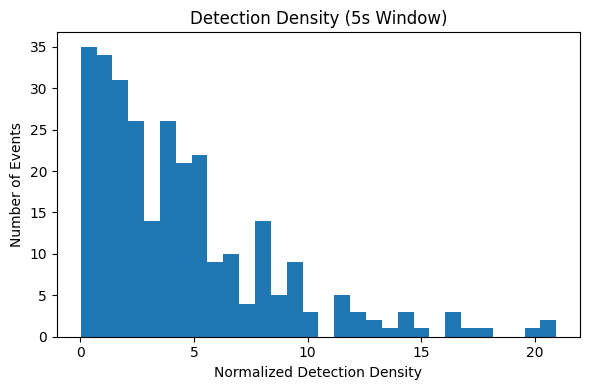

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
df["detection_density_5s"].hist(bins=30)
plt.title("Detection Density (5s Window)")
plt.xlabel("Normalized Detection Density")
plt.ylabel("Number of Events")
plt.tight_layout()
plt.grid(False)
plt.show()

2️⃣ Detection density (10s window)

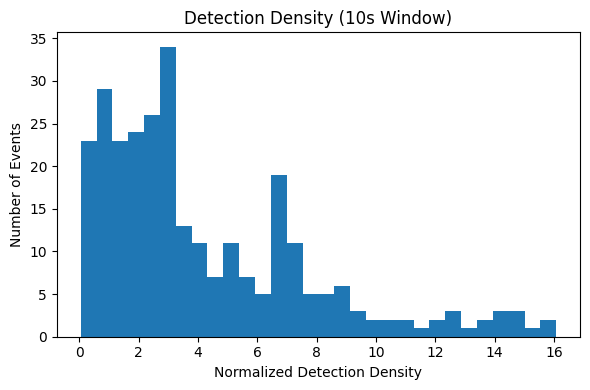

In [13]:
plt.figure(figsize=(6, 4))
df["detection_density_10s"].hist(bins=30)
plt.title("Detection Density (10s Window)")
plt.xlabel("Normalized Detection Density")
plt.ylabel("Number of Events")
plt.tight_layout()
plt.grid(False)
plt.show()

3️⃣ Consecutive fire frames — TEMPORAL STABILITY

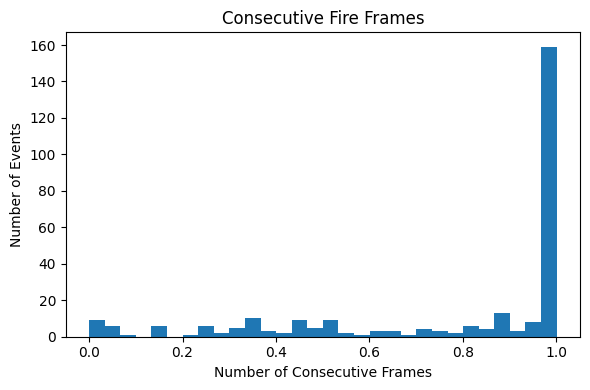

In [14]:
plt.figure(figsize=(6, 4))
df["consecutive_fire_ratio"].hist(bins=30)
plt.title("Consecutive Fire Frames")
plt.xlabel("Number of Consecutive Frames")
plt.ylabel("Number of Events")
plt.tight_layout()
plt.grid(False)
plt.show()


4️⃣ Bounding box area growth — SPATIAL BEHAVIOR

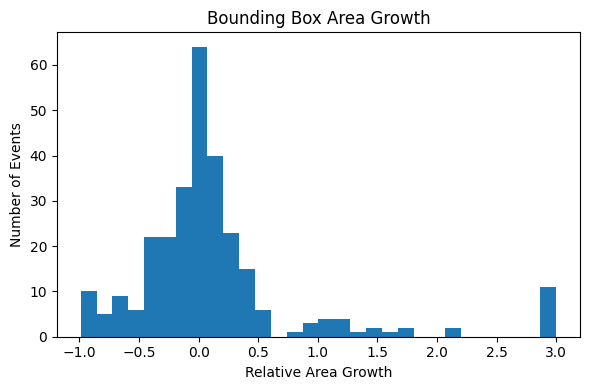

In [15]:
plt.figure(figsize=(6, 4))
df["bbox_area_growth"].hist(bins=30)
plt.title("Bounding Box Area Growth")
plt.xlabel("Relative Area Growth")
plt.ylabel("Number of Events")
plt.tight_layout()
plt.grid(False)
plt.show()

5️⃣ (Optional) Confidence distribution

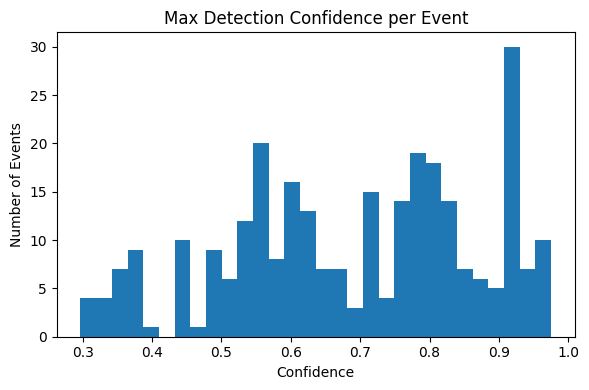

In [16]:
plt.figure(figsize=(6, 4))
df["max_confidence"].hist(bins=30)
plt.title("Max Detection Confidence per Event")
plt.xlabel("Confidence")
plt.ylabel("Number of Events")
plt.tight_layout()
plt.grid(False)
plt.show()

Current label distribution (evidence)

In [17]:
import pandas as pd

df = pd.read_csv(r"C:\Users\User\Desktop\project\video_pipeline\ml\training\event_dataset_labeled.csv")

df["transmission_decision"].value_counts()

transmission_decision
SEND_METADATA    126
DROP             123
SEND_FULL         37
Name: count, dtype: int64

In [18]:
df.shape

(286, 22)

In [19]:
df.describe()

,video_id,window_start_sec,window_end_sec,representative_frame_id,max_confidence,avg_confidence,object_count,fire_smoke_ratio,bbox_area_ratio,detection_density_5s,detection_density_10s,avg_confidence_5s,consecutive_fire_ratio,bbox_area_growth,brightness,blur_score,motion_level
count,286.000000,286.000000,286.000000,286.000000,286.000000,286.000000,286.000000,286.000000,286.000000,286.000000,286.000000,286.000000,286.000000,286.000000,286.000000,286.000000,286.000000
mean,5.465035,28.321678,33.321678,4207.276224,0.689704,0.416012,5.176305,0.748490,0.558340,4.463026,4.203976,0.416012,0.782897,0.137976,107.621293,448.371372,6.108094
std,2.039221,23.562415,23.562415,2075.185118,0.178575,0.075411,4.966368,0.265516,0.236682,4.037554,3.578146,0.075411,0.312478,0.749902,26.268215,220.996300,7.952394
min,1.000000,0.000000,5.000000,146.000000,0.296728,0.268648,1.000000,0.000000,0.005356,0.008000,0.052000,0.268648,0.000000,-0.989999,49.609883,105.040181,0.463803
25%,4.000000,7.000000,12.000000,2452.750000,0.557175,0.364054,1.823647,0.528477,0.405018,1.544000,1.581582,0.364054,0.527395,-0.195658,86.655197,269.339433,2.510482
50%,5.000000,22.500000,27.500000,4514.000000,0.716475,0.412673,3.865663,0.835918,0.639418,3.559108,3.045843,0.412673,0.994328,0.004532,114.409847,435.982049,4.951960
75%,6.000000,46.000000,51.000000,5775.750000,0.825256,0.474432,6.096667,1.000000,0.730207,5.885886,6.468352,0.474432,1.001001,0.217189,123.363253,559.331539,7.380395
max,11.000000,85.000000,90.000000,7896.000000,0.975177,0.583440,22.555556,1.000000,0.859139,20.947614,16.072739,0.583440,1.001001,3.000000,194.446000,1097.738685,74.921000


In [20]:
df.head()

,video_id,video_name,camera_name,window_start_sec,window_end_sec,representative_frame_id,representative_frame_name,representative_frame_path,max_confidence,avg_confidence,...,bbox_area_ratio,detection_density_5s,detection_density_10s,avg_confidence_5s,consecutive_fire_ratio,bbox_area_growth,brightness,blur_score,motion_level,transmission_decision
0,1,cam01_car_fire.mp4,cam01,0,5,146,cam01_frame_146.jpg,video_pipeline/output/saved_frames/cam01_frame...,0.957943,0.504024,...,0.728223,4.680000,2.340000,0.504024,0.993333,0.117237,118.250464,309.147544,15.139262,SEND_FULL
1,1,cam01_car_fire.mp4,cam01,1,6,146,cam01_frame_146.jpg,video_pipeline/output/saved_frames/cam01_frame...,0.957943,0.526409,...,0.702688,4.313333,2.550000,0.526409,1.000000,-0.433285,119.294667,309.776753,14.172786,SEND_FULL
2,1,cam01_car_fire.mp4,cam01,2,7,202,cam01_frame_202.jpg,video_pipeline/output/saved_frames/cam01_frame...,0.975177,0.543022,...,0.702688,4.306667,3.083333,0.543022,1.000000,0.130569,121.708687,327.499147,16.139979,SEND_FULL
3,1,cam01_car_fire.mp4,cam01,3,8,202,cam01_frame_202.jpg,video_pipeline/output/saved_frames/cam01_frame...,0.975177,0.543454,...,0.784026,4.793333,3.810000,0.543454,1.000000,0.323905,121.043020,359.171380,17.321970,SEND_FULL
4,1,cam01_car_fire.mp4,cam01,4,9,202,cam01_frame_202.jpg,video_pipeline/output/saved_frames/cam01_frame...,0.975177,0.564547,...,0.784026,5.666667,4.630000,0.564547,1.000000,1.039767,119.742680,393.648213,17.445870,SEND_FULL


1️⃣ Feature vs Label behavior

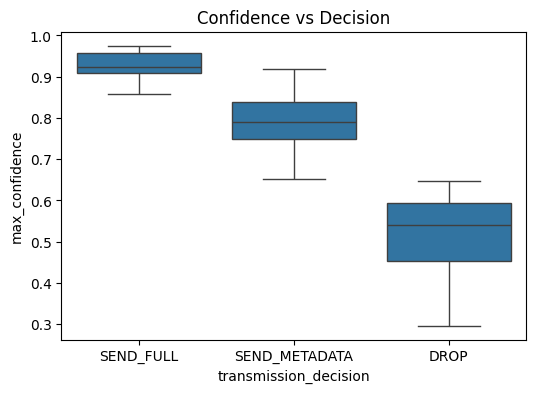

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.boxplot(x="transmission_decision", y="max_confidence", data=df)
plt.title("Confidence vs Decision")
plt.show()

Consecutive Fire Ratio

<Axes: >

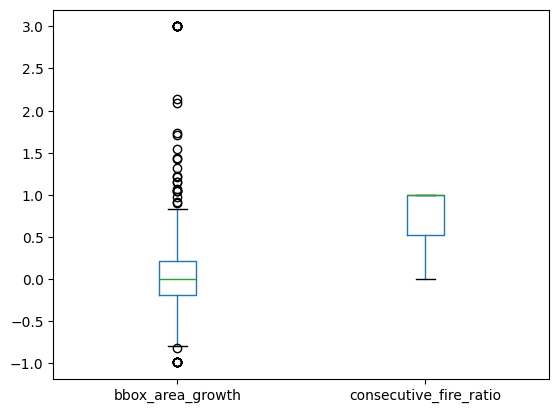

In [22]:
df.boxplot(column=["bbox_area_growth", "consecutive_fire_ratio"],grid=False)


Correlation check

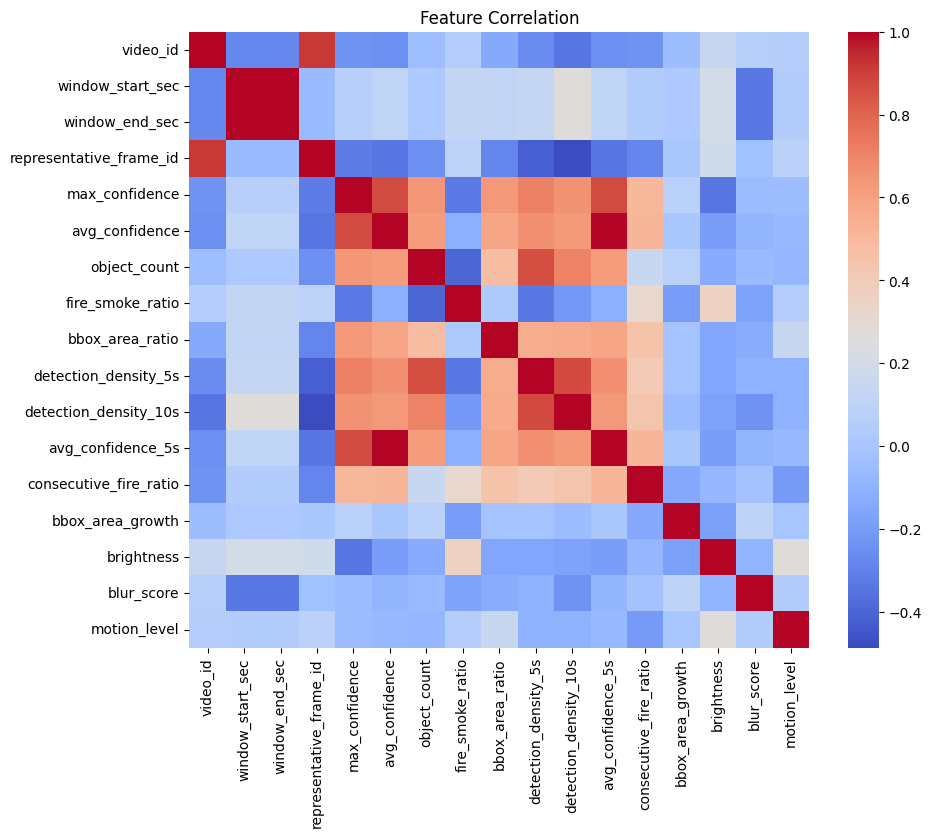

In [23]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

consecutive_fire_ratio histogram

<Axes: >

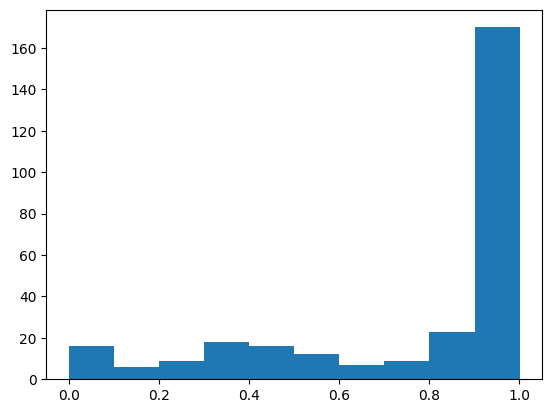

In [24]:
df["consecutive_fire_ratio"].hist(grid=False)

<Axes: >

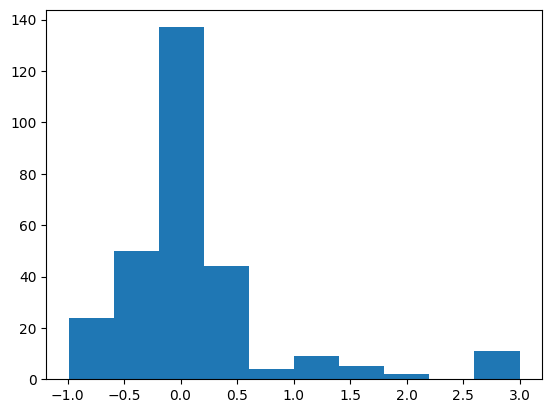

In [25]:
df["bbox_area_growth"].hist(grid=False)

Outliers check

In [26]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
video_id,286.0,5.465035,2.039221,1.000000,4.000000,5.000000,6.000000,11.000000
window_start_sec,286.0,28.321678,23.562415,0.000000,7.000000,22.500000,46.000000,85.000000
window_end_sec,286.0,33.321678,23.562415,5.000000,12.000000,27.500000,51.000000,90.000000
representative_frame_id,286.0,4207.276224,2075.185118,146.000000,2452.750000,4514.000000,5775.750000,7896.000000
max_confidence,286.0,0.689704,0.178575,0.296728,0.557175,0.716475,0.825256,0.975177
avg_confidence,286.0,0.416012,0.075411,0.268648,0.364054,0.412673,0.474432,0.583440
object_count,286.0,5.176305,4.966368,1.000000,1.823647,3.865663,6.096667,22.555556
fire_smoke_ratio,286.0,0.748490,0.265516,0.000000,0.528477,0.835918,1.000000,1.000000
bbox_area_ratio,286.0,0.558340,0.236682,0.005356,0.405018,0.639418,0.730207,0.859139
detection_density_5s,286.0,4.463026,4.037554,0.008000,1.544000,3.559108,5.885886,20.947614
